In [1]:
import pandas as pd
data = pd.read_csv(r"C:\Users\jayal\Desktop\customer_summary.csv")

<bound method NDFrame.head of     Customer_id;"customername";"gender";"age";"total_purchases";"total_spent";"avg_purchase_value";"churn"
0    44605;"John Rivera";"Female";31;5;10755.0;2151...                                                    
1    13738;"Lauren Johnson";"Female";27;5;14483.0;2...                                                    
2    33969;"Carol Allen";"Male";27;7;25266.0;3609.4...                                                    
3    42650;"Curtis Smith";"Female";20;13;35366.0;27...                                                    
4      24053;"Jose Green";"Male";53;5;12253.0;2450.6;0                                                    
..                                                 ...                                                    
627   19187;"Connor Rose";"Male";30;5;14072.0;2814.4;0                                                    
628  31394;"Sheryl Hernandez";"Male";70;13;37529.0;...                                                    
629  32

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [56]:
data = pd.read_csv(r"C:\Users\jayal\Desktop\customer_summary.csv",sep=';')

In [57]:
X = data.drop(columns=['Customer_id', 'customername', 'churn'])
y = data['churn']



In [48]:
X = pd.get_dummies(X, drop_first=True)

# 5️⃣ Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [49]:
model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)

# 7️⃣ Accuracy
y_pred = model.predict(X_scaled)
print("Accuracy:", accuracy_score(y, y_pred))

Accuracy: 0.8306962025316456


In [50]:
coefficients = model.coef_[0]
abs_coeff = np.abs(coefficients)
strongest_index = np.argmax(abs_coeff)

feature_name = X.columns[strongest_index]
print("Strongest Feature:", feature_name)


Strongest Feature: total_purchases


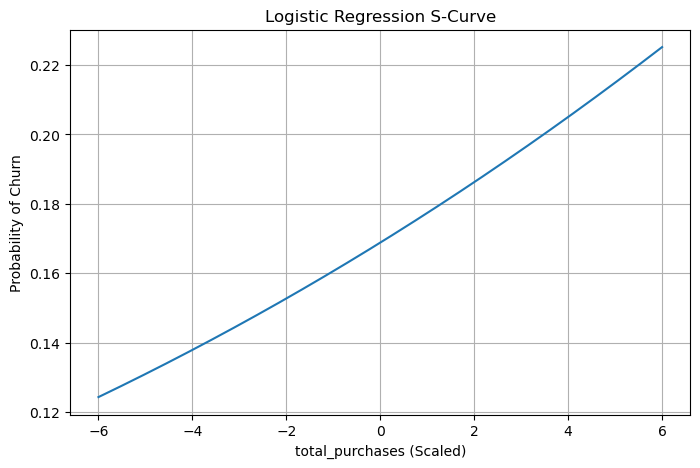

In [52]:
# 9️⃣ Create S-curve for strongest feature
x_values = np.linspace(-6,6,400)
   

b0 = model.intercept_[0]
b1 = model.coef_[0][strongest_index]

y_prob = 1 / (1 + np.exp(-(b0 + b1 * x_values)))

# 🔟 Plot
plt.figure(figsize=(8,5))
plt.plot(x_values, y_prob)
plt.xlabel(feature_name + " (Scaled)")
plt.ylabel("Probability of Churn")
plt.title("Logistic Regression S-Curve")
plt.grid(True)
plt.show()